<p><img alt="UdeA logo" style="height: 180px !important; width: auto;" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="right" hspace="10px" vspace="0px"></p>


<h1> <b>Laboratorio 03 Intuición estadística

Física Computacional II 2026-2</b> </h1>

</div>

<!-- <br> le permite hacer espacios -->
<br>

<hr size=10 noshade color="green">
<p>


<div align="left">       

<h3><i><b>Felipe Quitian Gallego</b><br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

# Librerias

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, ShuffleSplit, learning_curve
from sklearn.svm import SVC
from scipy.stats import multivariate_normal
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_digits

# Modelos generados en la sesión 3

Escribimos las funciones y datos necesarios de la sesion 3

In [2]:
def data( mu=[1,1], mu1=[-2,2], cov=[[1.0, 0.0], [0.0, 1.0]] , cov1= [[1.0, -0.5], [-0.5, 1.0]]   ):# Caso mas visible
  rv = multivariate_normal(mu, cov)
  rv1 = multivariate_normal(mu1, cov1)
  return rv, rv1

def sample(N1= 1000, N2 = 100, r = 0.2):
  X_t = np.concatenate([rv.rvs(N1, random_state = r  ), rv1.rvs(N2,random_state = r)]) # Todos los datos en la misma distribución,
  y   = np.concatenate([np.zeros(N1), np.ones(N2) ]  )
  return X_t, y

rv, rv1 = data( mu=[1.2,1.4], mu1=[1.4,-1.4],
     cov=[[1.0, -0.8], [-0.8, 1.0]] ,
     cov1= [[1.0, 0.8], [0.8, 1.0]])
X_t, y = sample(N1 = 100, N2 = 100, r = 10)


In [3]:
# @title Libs codes: Meshgrid and learning curves
def make_meshgrid(x, y, h=0.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy


def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out


def plot_contoursExact(ax, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

# https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html
def plot_learning_curve(
    estimator,
    title,
    X,
    y,
    axes=None,
    ylim=None,
    cv=None,
    n_jobs=None,
    train_sizes=np.linspace(0.1, 1.0, 5),
):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs fit times curve, the fit times vs score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing `fit` and `predict` methods which
        will be cloned for each validation.

    title : str
        Title for the chart.

    X : array-like of shape (n_samples, n_features)
        Training vector, where ``n_samples`` is the number of samples and
        ``n_features`` is the number of features.

    y : array-like of shape (n_samples) or (n_samples, n_features)
        Target relative to ``X`` for classification or regression;
        None for unsupervised learning.

    axes : array-like of shape (3,), default=None
        Axes to use for plotting the curves.

    ylim : tuple of shape (2,), default=None
        Defines minimum and maximum y-values plotted, e.g. (ymin, ymax).

    cv : int, cross-validation generator or an iterable, default=None
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:

          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, default=None
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like of shape (n_ticks,)
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the ``dtype`` is float, it is regarded
        as a fraction of the maximum size of the training set (that is
        determined by the selected validation method), i.e. it has to be within
        (0, 1]. Otherwise it is interpreted as absolute sizes of the training
        sets. Note that for classification the number of samples usually have
        to be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        return_times=True,
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r",
    )
    axes[0].fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g",
    )
    axes[0].plot(
        train_sizes, train_scores_mean, "o-", color="r", label="Training score"
    )
    axes[0].plot(
        train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation score"
    )
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, "o-")
    axes[1].fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.1,
    )
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_time vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, "o-")
    axes[2].fill_between(
        fit_times_mean,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
    )
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt

# Punto 1

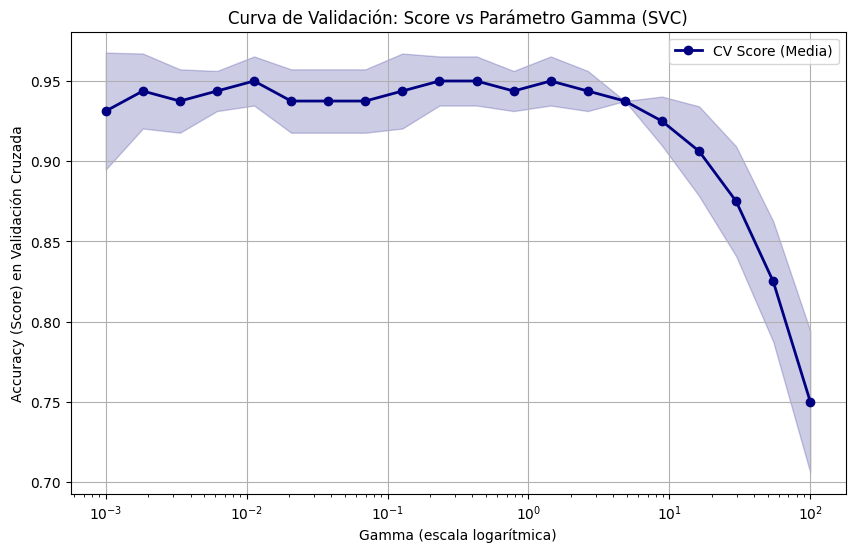

El mejor valor de gamma es: 0.0113
Con un score promedio en validación de: 0.9500


In [4]:
# 1. Dividimos los datos en 20% para test y 80% para entrenamiento
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_t, y, test_size=0.20, random_state=42
)

# 2. Definimos un rango de valores para evaluar el parámetro gamma
gamma_values = np.logspace(-3, 2, 20)
cv_scores_mean = []
cv_scores_std = []

# 3. Entrenamos el modelo SVC variando gamma y calculamos el score mediante validación cruzada
for g in gamma_values:
    svm_model = SVC(kernel='rbf', gamma=g)
    scores = cross_val_score(svm_model, X_train_val, y_train_val, cv=5, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

cv_scores_mean = np.array(cv_scores_mean)
cv_scores_std = np.array(cv_scores_std)

# 4. Construimos la curva del score en función del parámetro gamma
plt.figure(figsize=(10, 6))
plt.title("Curva de Validación: Score vs Parámetro Gamma (SVC)")
plt.xlabel("Gamma (escala logarítmica)")
plt.ylabel("Accuracy (Score) en Validación Cruzada")

# Graficamos la media y la banda de desviación estándar
plt.semilogx(gamma_values, cv_scores_mean, label="CV Score (Media)", color="navy", lw=2, marker='o')
plt.fill_between(gamma_values,
                 cv_scores_mean - cv_scores_std,
                 cv_scores_mean + cv_scores_std,
                 alpha=0.2, color="navy")

plt.legend(loc="best")
plt.grid(True)
plt.show()

# 5. Identificamos el mejor modelo
best_gamma_idx = np.argmax(cv_scores_mean)
best_gamma = gamma_values[best_gamma_idx]
print(f"El mejor valor de gamma es: {best_gamma:.4f}")
print(f"Con un score promedio en validación de: {cv_scores_mean[best_gamma_idx]:.4f}")

La grafica y el analisis nos demuestra que el mejor modelo se encuentra en el pico máximo de la gráfica, para el valor de $\gamma = 0.0113$, con un score de validación de 0.9500.

# Punto 2

Mejor parámetro gamma: 0.0113
Mejor score de validación: 0.9500


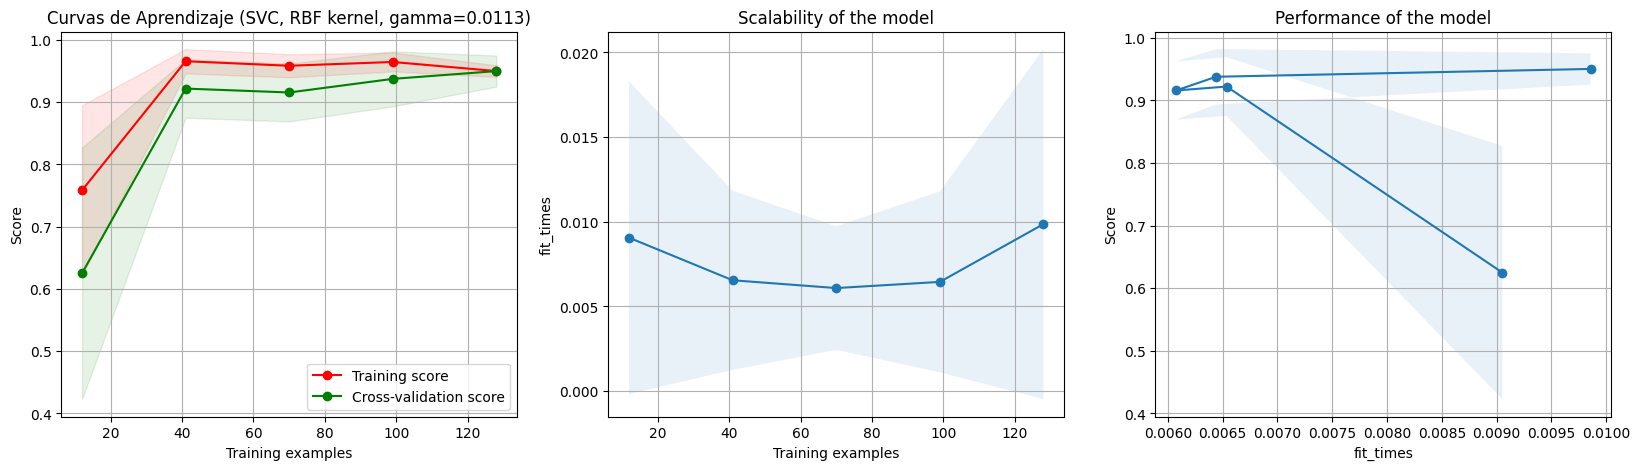

In [5]:

# Definimos el mismo espacio de búsqueda para gamma que en la parte 1
param_grid = {'gamma': np.logspace(-3, 2, 20)}

# Configuramos GridSearchCV con 5-fold cross validation
grid_search = GridSearchCV(
    estimator=SVC(kernel='rbf'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Entrenamos la búsqueda en rejilla con los datos de entrenamiento/validación
grid_search.fit(X_train_val, y_train_val)

best_gamma_grid = grid_search.best_params_['gamma']
best_score_grid = grid_search.best_score_

print(f"Mejor parámetro gamma: {best_gamma_grid:.4f}")
print(f"Mejor score de validación: {best_score_grid:.4f}")

# 2. Construimos las Curvas de Aprendizaje con el mejor modelo
best_svm_model = grid_search.best_estimator_

# Configuramos la estrategia de validación cruzada para la curva
cv_strategy = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

title = f"Curvas de Aprendizaje (SVC, RBF kernel, gamma={best_gamma_grid:.4f})"

# Graficamos
plot_learning_curve(
    estimator=best_svm_model,
    title=title,
    X=X_train_val,
    y=y_train_val,
    cv=cv_strategy,
    n_jobs=-1
)

plt.show()

El parámetro óptimo es $\gamma = 0.0113$ con un score de 0.9500, lo que descarta la existencia de sesgos visuales en la interpretación de la primera curva.

Comparando las Curvas de Aprendizaje, Training examples vs Score, vemos que el rendimiento del modelo sigue comportamientos predecibles. La gráfica muestra que la medida de entrenamiento, la línea roja, y la de validación cruzada, línea verde, convergen juntas bajo una dependencia asintótica, estabilizándose de forma conjunta en un valor de 0.9500 a medida que aumenta el tamaño de la muestra.

Dado que no hay una brecha grande y constante entre la curva roja y la verde podemos garantizar que no existe overfitting en el modelo. Por otro lado, el hecho de que ambas curvas converjan hacia un límite superior tan alto nos demuestra que tampoco hay evidencia de underfitting.

# Punto 3

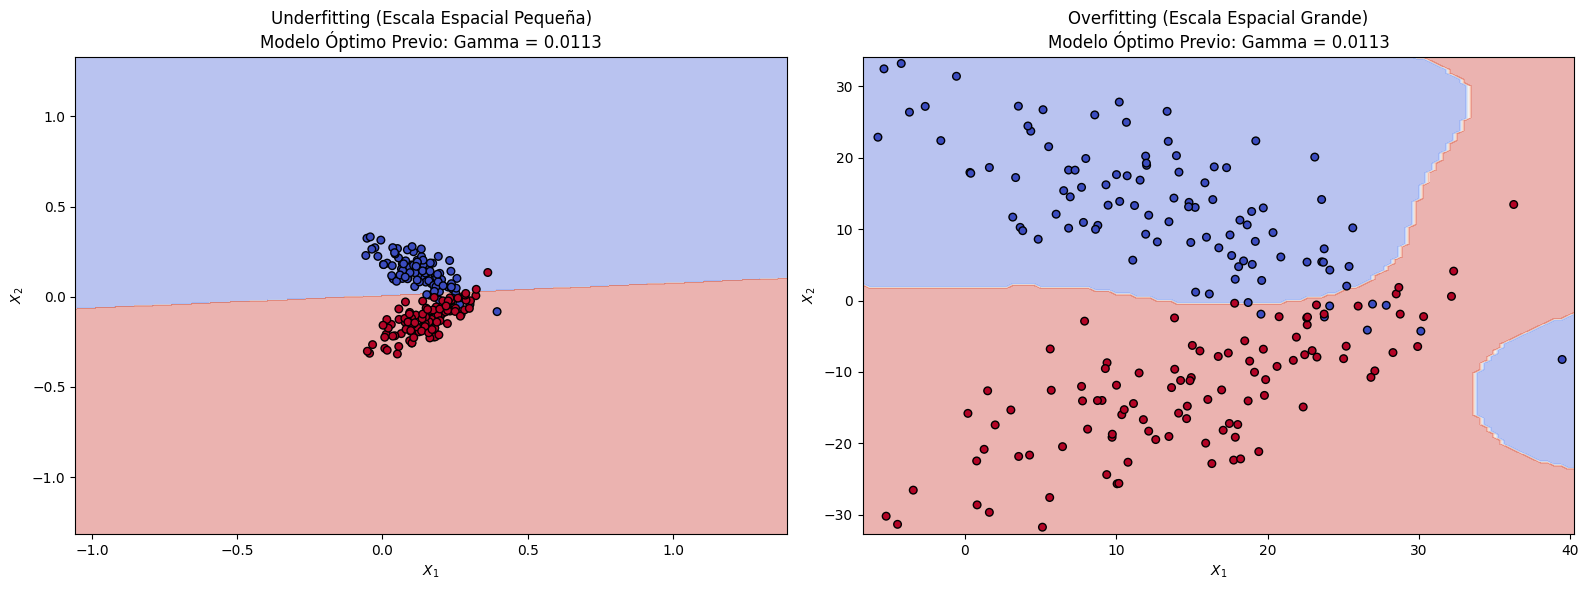

In [6]:
# Utilizamos el mejor gamma encontrado en el paso anterior
gamma_optimo = best_gamma_grid

# 1. UNDERFITTING
# Reducimos los valores de medias y covarianzas
rv, rv1 = data(mu=[0.12, 0.14], mu1=[0.14, -0.14],
               cov=[[0.01, -0.008], [-0.008, 0.01]],
               cov1=[[0.01, 0.008], [0.008, 0.01]])

X_under, y_under = sample(N1=100, N2=100, r=42)

svm_under = SVC(kernel='rbf', gamma=gamma_optimo)
svm_under.fit(X_under, y_under)

# 2. OVERFITTING
# Aumentamos los valores de medias y covarianzas.
rv, rv1 = data(mu=[12, 14], mu1=[14, -14],
               cov=[[100, -80], [-80, 100]],
               cov1=[[100, 80], [80, 100]])

X_over, y_over = sample(N1=100, N2=100, r=42)

svm_over = SVC(kernel='rbf', gamma=gamma_optimo)
svm_over.fit(X_over, y_over)

# Graficamos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Función auxiliar para graficar utilizando make_meshgrid y plot_contours del Colab
def plot_decision(ax, X, y, model, title):
    X0, X1 = X[:, 0], X[:, 1]
    h_dinamico = (X0.max() - X0.min()) / 100.0
    xx, yy = make_meshgrid(X0, X1, h=h_dinamico)

    plot_contours(ax, model, xx, yy, cmap=plt.cm.coolwarm, alpha=0.4)
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=30, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("$X_1$")
    ax.set_ylabel("$X_2$")

# Graficamos el Underfitting
plot_decision(axes[0], X_under, y_under, svm_under,
              f"Underfitting (Escala Espacial Pequeña)\nModelo Óptimo Previo: Gamma = {gamma_optimo:.4f}")

# Graficamos el Overfitting
plot_decision(axes[1], X_over, y_over, svm_over,
              f"Overfitting (Escala Espacial Grande)\nModelo Óptimo Previo: Gamma = {gamma_optimo:.4f}")

plt.tight_layout()
plt.show()

# Analisis y concluciones

Las gráficas de los escenarios de underfitting y overfitting, muestran patrones geométricos muy marcados, evidenciando que el parámetro gamma no es un valor de eficacia continua o universal, sino que se ajusta directamente con la escala espacial de los datos. Además, la distribución espacial con covarianzas reducidas de 0.01 muestra una subpoblación de predicciones con una frontera casi recta y simplificada frente a las agrupaciones.

Los gráficos de contorno nos muestran que al analizar el escenario de overfitting (covarianzas ampliadas a 100), la frontera de decisión es muy diferente de las demás, teniendo contornos completamente fragmentados, separándose drásticamente en forma de múltiples islas cerradas alrededor de puntos específicos de entrenamiento.

La comparación visual de estos dos escenarios extremos nos demuestra la dinámica de estos modelos. En el plano cartesiano de covarianzas altas, cada dato de la muestra está completamente aislado en su propia región de clasificación, por el contrario, en el plano de covarianzas muy bajas, ambas clases coexisten sin que el modelo tenga la flexibilidad para delinearlas.